# CUSUM Bubble Detection — Data Preparation

Generates CUSUM-based bubble dummy columns (`_BD`) for all four metals and saves the result
as `R/df_master_cusum.csv` in the **same format** as `R/df_master.csv` (semicolon-separated, comma decimal).

**This mirrors the role of `notebooks/analysis/lppls_data_prep.ipynb`** but replaces LPPLS
with a rolling multi-scale CUSUM structural break test.

| Step | Description |
|------|-------------|
| 1 | Load base dataset (`R/data_R/df_master.csv` preferred) — prices + macro/market from R |
| 2 | Apply rolling CUSUM at two scales (window=60 and window=120) to each metal's log-price series |
| 3 | Union of both scales, then smooth (fill gaps ≤5 days, remove episodes <10 days) |
| 4 | Apply trend filter: OLS slope > 0 on price *levels* over [t−5,…,t] — same spirit as metals30 / GSADF |
| 5 | Compare CUSUM bubble prevalence with original GSADF labels |
| 6 | Save `df_master_cusum.csv` with replaced `_BD` columns |

**Reference:** Homm, U. & Breitung, J. (2012). *Testing for Speculative Bubbles in Stock Markets.*

**⚠ Runtime:** The rolling CUSUM with `window=120` is O(T²) in naive implementations.
The optimized version here is O(T) and runs in seconds per metal.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings
from pathlib import Path
warnings.filterwarnings('ignore')


def trend_filter_ols_window(raw, prices, lag=5):
    """Keep raw[i]==1 only if OLS slope of price *levels* vs time on [i-lag, ..., i] is > 0 (metals30 / GSADF-style)."""
    raw = np.asarray(raw, dtype=int).copy()
    prices = np.asarray(prices, dtype=float)
    for i in range(len(raw)):
        if raw[i] != 1:
            continue
        if i < lag:
            raw[i] = 0
            continue
        seg = prices[i - lag : i + 1]
        if len(seg) < 3 or np.nanstd(seg) == 0:
            raw[i] = 0
            continue
        x = np.arange(len(seg), dtype=float)
        slope = np.polyfit(x, seg, 1)[0]
        if not np.isfinite(slope) or slope <= 0:
            raw[i] = 0
    return raw


plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
os.makedirs('../../outputs', exist_ok=True)

print('Packages loaded.')


Packages loaded.


## 1. Load Base Dataset

`R/data_R/df_master.csv` (fallback: `R/df_master.csv`) supplies prices and macro columns.
If `R/df_master_gsadf.csv` exists, its `*_BD` columns are merged in so GSADF reference matches your latest exuber run.


In [2]:
_repo = Path('../../').resolve()
_base_candidates = [
    _repo / 'R' / 'data_R' / 'df_master.csv',
    _repo / 'R' / 'df_master.csv',
]
_master = next((p for p in _base_candidates if p.is_file()), None)
if _master is None:
    raise FileNotFoundError('df_master.csv not found under R/data_R/ or R/')
print('Panel (prices + macro):', _master)
df = pd.read_csv(_master, sep=';', decimal=',', index_col=0)
df['Date'] = pd.to_datetime(df['Date']).dt.normalize()
df = df.sort_values('Date').reset_index(drop=True)

metals     = {'Cobalt': 'CODALY', 'Copper': 'CUDALY', 'Lithium': 'LIDALY', 'Nickel': 'NIDALY'}

_gsadf_candidates = [
    _repo / 'R' / 'df_master_gsadf.csv',
    _repo / 'R' / 'data_R' / 'df_master_gsadf.csv',
]
_gsadf_path = next((p for p in _gsadf_candidates if p.is_file()), None)
if _gsadf_path is not None:
    g = pd.read_csv(_gsadf_path, sep=';', decimal=',', index_col=0)
    g['Date'] = pd.to_datetime(g['Date']).dt.normalize()
    bd_only = [c for c in g.columns if c.endswith('_BD')]
    if bd_only:
        df = df.drop(columns=bd_only, errors='ignore').merge(
            g[['Date'] + bd_only], on='Date', how='left'
        )
        df[bd_only] = df[bd_only].fillna(0).astype(int)
    print('GSADF *_BD merged from:', _gsadf_path)
else:
    print('No df_master_gsadf.csv — *_BD are whatever is stored in the panel (may be an older GSADF run).')

bubble_cols = [c for c in df.columns if c.endswith('_BD')]

print(f'Dataset: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Period:  {df["Date"].min().date()} to {df["Date"].max().date()}')
print()
print('GSADF bubble prevalence (reference):')
for name, col in metals.items():
    bd = df[col + '_BD']
    print(f'  {name:10s}: {int(bd.sum()):4d} days  ({100*bd.mean():.1f}%)')


Panel (prices + macro): C:\Users\user\OneDrive - Uniwersytet Ekonomiczny w Poznaniu\Dokumenty\Publikacje\Metals\metals\R\data_R\df_master.csv
GSADF *_BD merged from: C:\Users\user\OneDrive - Uniwersytet Ekonomiczny w Poznaniu\Dokumenty\Publikacje\Metals\metals\R\df_master_gsadf.csv
Dataset: 2152 rows × 21 columns
Period:  2017-05-10 to 2025-10-31

GSADF bubble prevalence (reference):
  Cobalt    :  135 days  (6.3%)
  Copper    :   24 days  (1.1%)
  Lithium   :  466 days  (21.7%)
  Nickel    :   11 days  (0.5%)


## 2. CUSUM Bubble Detection (Rolling Multi-Scale)

Sequential CUSUM statistic for the one-sided explosive alternative:

$$\text{CUSUM}(\tau) = \frac{1}{\hat{\sigma}\sqrt{w}} \sum_{t=\tau-w}^{\tau} \Delta \ln p_t$$

where $\Delta \ln p_t$ are log-price first differences and $\hat{\sigma}^2 = w^{-1}\sum(\Delta\ln p_t)^2$
(local RMS). A bubble is flagged when $\max_{t\leq\tau}\text{CUSUM}(t) > \theta = 2.0$ (standard deviations).

**Two scales are combined:**
- Short window: $w = 60$ days — catches short, sharp explosive episodes
- Long window: $w = 120$ days — catches sustained exponential phases

**Union** of both scales ensures sensitivity across episode lengths. A **smoothing** step then
fills gaps ≤ 5 days and removes isolated episodes shorter than 10 days.

In [3]:
def cusum_bubble_detector(log_prices, window=120, threshold_sigma=2.0):
    """
    Rolling CUSUM bubble detector on log-price first differences.
    
    For each day `end`, considers the window [end-window, end) of log-return differences.
    Computes CUSUM / (local_sigma * sqrt(window)). Flags `end` if max CUSUM > threshold_sigma.
    
    One-sided test: only detects explosive *upward* behaviour (positive returns dominating).
    Returns a binary array of length len(log_prices).
    """
    T  = len(log_prices)
    dy = np.diff(log_prices)           # length T-1
    bubble = np.zeros(T, dtype=int)

    for end in range(window, T):
        start   = end - window
        segment = dy[start:end]
        local_sigma = np.sqrt(np.mean(segment ** 2))
        if local_sigma < 1e-10:
            continue
        cusum = np.cumsum(segment) / (local_sigma * np.sqrt(window))
        if np.max(cusum) > threshold_sigma:
            bubble[end] = 1

    return bubble


def smooth_bubble_labels(bubble, min_gap=5, min_duration=10):
    """
    Post-process binary bubble labels:
    1. Fill gaps shorter than min_gap days (bridge adjacent episodes)
    2. Remove episodes shorter than min_duration days (remove noise)
    """
    result = bubble.copy()

    # Pass 1: fill small gaps
    in_gap, gap_start = False, 0
    for i in range(len(result)):
        if result[i] == 0 and (i == 0 or result[i - 1] == 1):
            gap_start = i
            in_gap    = True
        elif result[i] == 1 and in_gap:
            if i - gap_start <= min_gap:
                result[gap_start:i] = 1
            in_gap = False

    # Pass 2: remove short episodes
    in_ep, ep_start = False, 0
    for i in range(len(result)):
        if result[i] == 1 and not in_ep:
            ep_start = i
            in_ep    = True
        elif (result[i] == 0 or i == len(result) - 1) and in_ep:
            if i - ep_start < min_duration:
                result[ep_start:i] = 0
            in_ep = False

    return result


# ── Apply to all metals ─────────────────────────────────────────────────────
WINDOW_SHORT     = 60
WINDOW_LONG      = 120
THRESHOLD_SIGMA  = 2.0
MIN_GAP          = 5
MIN_DURATION     = 10

cusum_raw_flags = {}   # before trend filter
cusum_smoothed  = {}   # after smoothing, before trend filter

print('CUSUM — Rolling Multi-Scale Detection')
print(f'  Windows: {WINDOW_SHORT} (short) + {WINDOW_LONG} (long)')
print(f'  Threshold: {THRESHOLD_SIGMA}σ')
print(f'  Smoothing: fill gaps ≤{MIN_GAP} days, remove episodes <{MIN_DURATION} days')
print('=' * 60)
print(f'{"Metal":10s}  {"Short flags":>11s}  {"Long flags":>10s}  {"Union":>5s}  {"Smoothed":>8s}')
print('-' * 55)

for metal, col in metals.items():
    prices    = df[col].values
    log_p     = np.log(np.maximum(prices, 0.001))

    cs_short  = cusum_bubble_detector(log_p, window=WINDOW_SHORT,  threshold_sigma=THRESHOLD_SIGMA)
    cs_long   = cusum_bubble_detector(log_p, window=WINDOW_LONG,   threshold_sigma=THRESHOLD_SIGMA)

    union     = ((cs_short == 1) | (cs_long == 1)).astype(int)
    smoothed  = smooth_bubble_labels(union, min_gap=MIN_GAP, min_duration=MIN_DURATION)

    cusum_raw_flags[metal] = union
    cusum_smoothed[metal]  = smoothed

    print(f'{metal:10s}  {int(cs_short.sum()):11d}  {int(cs_long.sum()):10d}  '
          f'{int(union.sum()):5d}  {int(smoothed.sum()):8d}')

print()
print('Done.')


CUSUM — Rolling Multi-Scale Detection
  Windows: 60 (short) + 120 (long)
  Threshold: 2.0σ
  Smoothing: fill gaps ≤5 days, remove episodes <10 days
Metal       Short flags  Long flags  Union  Smoothed
-------------------------------------------------------
Cobalt              198         236    295       280
Copper              137         180    285       306
Lithium             321         391    510       508
Nickel              112          56    158       178

Done.


## 3. Trend Filter

Mirrors `lppls_data_prep.ipynb`: for each day with a raw CUSUM flag after smoothing,
we keep it only if the **OLS slope** of price vs. time on **[t−5, …, t]** is **> 0**.
This removes detections that fire during a price plateau or decline.

In [4]:
TREND_LAG = 5   # OLS window [t-5, …, t]; slope > 0 keeps flag (aligned with lppls_data_prep)

cusum_bubbles = {}   # final filtered flags

print('Trend filter (OLS slope > 0 on price window [t-5,…,t]):')
print(f'{"Metal":10s}  {"Smoothed":>8s}  {"Filtered":>8s}  {"Removed":>7s}')
print('-' * 40)

for metal, col in metals.items():
    prices   = df[col].values
    raw      = cusum_smoothed[metal].copy()
    filtered = trend_filter_ols_window(raw, prices, lag=TREND_LAG)

    cusum_bubbles[metal] = filtered

    n_raw  = int(raw.sum())
    n_filt = int(filtered.sum())
    print(f'{metal:10s}  {n_raw:8d}  {n_filt:8d}  {n_raw - n_filt:7d}')


Trend filter (OLS slope > 0 on price window [t-5,…,t]):
Metal       Smoothed  Filtered  Removed
----------------------------------------
Cobalt           280       111      169
Copper           306       194      112
Lithium          508       220      288
Nickel           178        92       86


## 4. Diagnostics — Bubble Period Plots & Prevalence Comparison

Visualize the final CUSUM bubble periods and compare prevalence with the original GSADF labels.

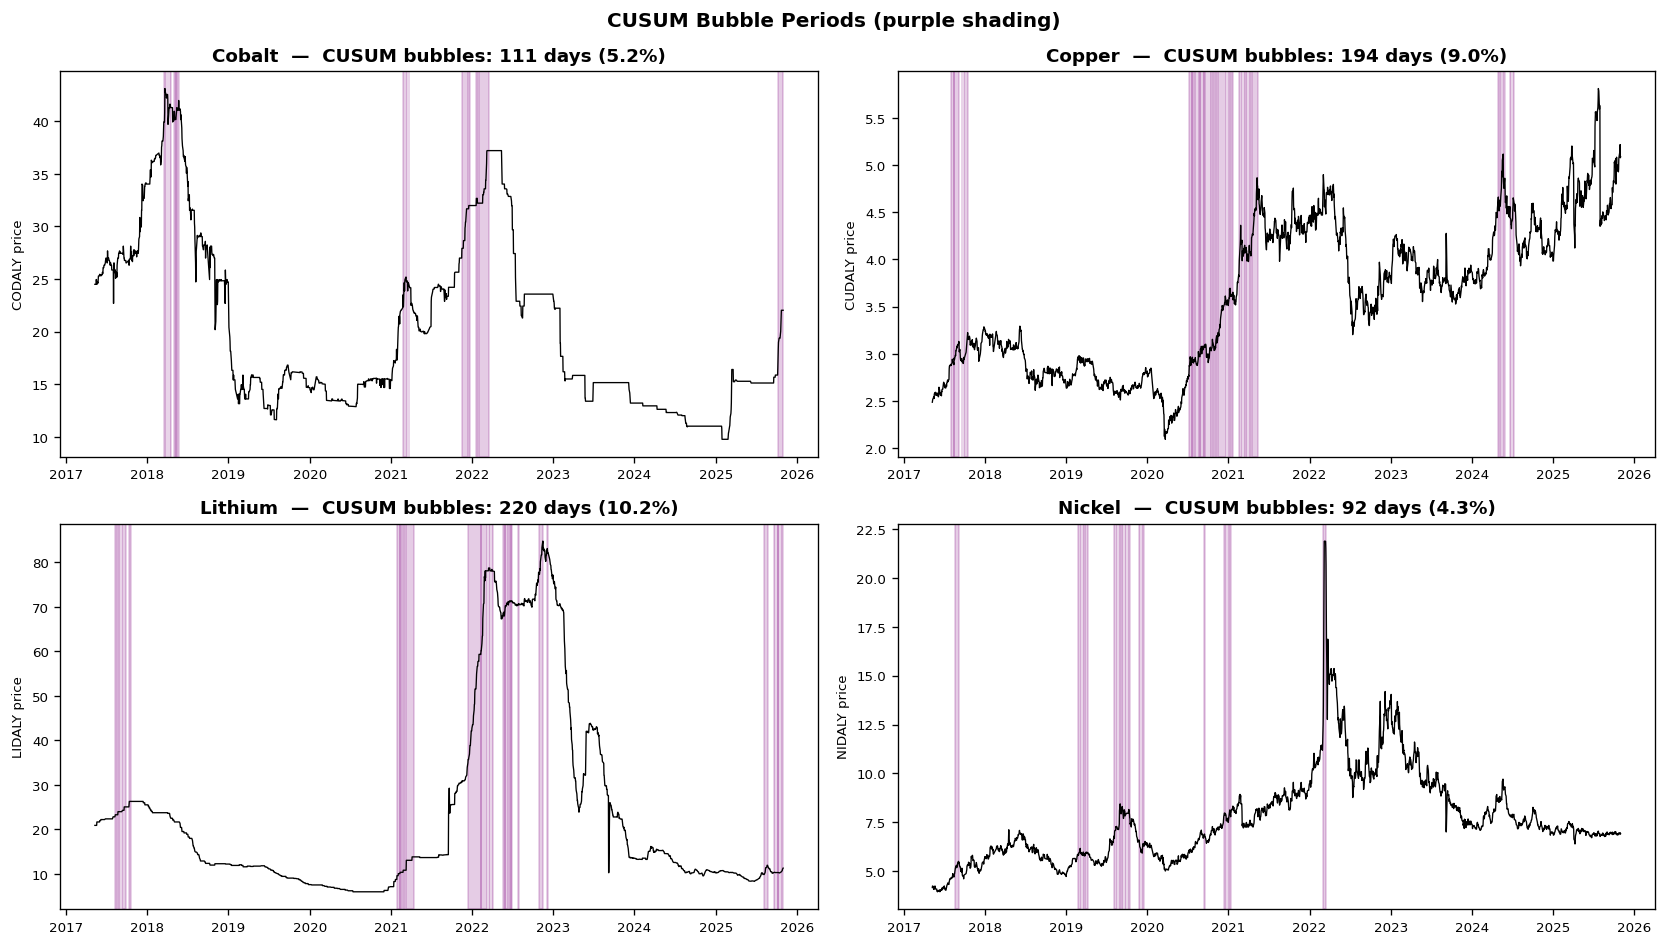

In [5]:
# Price + CUSUM bubble shading (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)

for idx, (metal, col) in enumerate(metals.items()):
    ax  = axes.flat[idx]
    bub = cusum_bubbles[metal]
    n_b = int(bub.sum())

    ax.plot(df['Date'], df[col], color='black', lw=0.8)

    in_b = False
    for i in range(len(bub)):
        if bub[i] == 1 and not in_b:
            s = df['Date'].iloc[i]; in_b = True
        elif (bub[i] == 0 or i == len(bub) - 1) and in_b:
            ax.axvspan(s, df['Date'].iloc[i], color='purple', alpha=0.2)
            in_b = False

    ax.set_title(f'{metal}  —  CUSUM bubbles: {n_b} days ({100*n_b/len(df):.1f}%)',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel(f'{col} price', fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle('CUSUM Bubble Periods (purple shading)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/cusum_bubble_timelines.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()


In [6]:
# Prevalence comparison table
# Prevalence comparison — GSADF side re-read from disk when available
_gsadf_cmp = None
_p = globals().get('_gsadf_path')
if _p is not None:
    _gcmp = pd.read_csv(_p, sep=';', decimal=',', index_col=0)
    _gcmp['Date'] = pd.to_datetime(_gcmp['Date']).dt.normalize()
    _bd_cmp = [c for c in _gcmp.columns if c.endswith('_BD')]
    if _bd_cmp:
        _gsadf_cmp = df[['Date']].merge(_gcmp[['Date'] + _bd_cmp], on='Date', how='left')
        _gsadf_cmp[_bd_cmp] = _gsadf_cmp[_bd_cmp].fillna(0).astype(int)
    print('GSADF column source for this table:', _p)
else:
    print('GSADF column source for this table: panel *_BD (no df_master_gsadf.csv at load time)')

print(f'{"Metal":10s} | {"GSADF days":>10s} | {"GSADF %":>8s} | {"CUSUM days":>10s} | {"CUSUM %":>8s}')
print('-' * 60)
for metal, col in metals.items():
    if _gsadf_cmp is not None:
        gsadf_n = int(_gsadf_cmp[col + '_BD'].sum())
    else:
        gsadf_n = int(df[col + '_BD'].sum())
    gsadf_pct = 100 * gsadf_n / len(df)
    cusum_n   = int(cusum_bubbles.get(metal, np.zeros(len(df))).sum())
    cusum_pct = 100 * cusum_n / len(df)
    print(f'{metal:10s} | {gsadf_n:10d} | {gsadf_pct:7.1f}% | {cusum_n:10d} | {cusum_pct:7.1f}%')


GSADF column source for this table: C:\Users\user\OneDrive - Uniwersytet Ekonomiczny w Poznaniu\Dokumenty\Publikacje\Metals\metals\R\df_master_gsadf.csv
Metal      | GSADF days |  GSADF % | CUSUM days |  CUSUM %
------------------------------------------------------------
Cobalt     |        135 |     6.3% |        111 |     5.2%
Copper     |         24 |     1.1% |        194 |     9.0%
Lithium    |        466 |    21.7% |        220 |    10.2%
Nickel     |         11 |     0.5% |         92 |     4.3%


## 5. Assemble & Save

Replace the `_BD` columns in `df_master` with the CUSUM-filtered flags and save as
`R/df_master_cusum.csv` using `sep=';', decimal=','` — identical format to `df_master.csv`.

Also saves the raw smoothed (pre-trend-filter) CUSUM flags to `R/cusum_flags.csv`
for threshold sensitivity analysis.

In [7]:
df_out = df.copy()

# Replace _BD columns with CUSUM flags
for metal, col in metals.items():
    bd_col = col + '_BD'
    if metal in cusum_bubbles:
        df_out[bd_col] = cusum_bubbles[metal].astype(int)
    else:
        df_out[bd_col] = 0
        print(f'WARNING: {metal} CUSUM failed — {bd_col} set to 0.')

# Sanity checks
assert list(df_out.columns) == list(df.columns), 'Column mismatch!'
assert len(df_out) == len(df), 'Row count changed!'
print(f'Output shape: {df_out.shape}')
print(f'Columns:      {list(df_out.columns)}')
print()

# Save — same format as R write.csv2
out_path = '../../R/df_master_cusum.csv'
df_out.to_csv(out_path, sep=';', decimal=',')

size_kb = os.path.getsize(out_path) / 1024
print(f'Saved → {out_path}  ({size_kb:.1f} KB)')
print()

# Also save raw smoothed flags (before trend filter) for sensitivity analysis
flags_df = pd.DataFrame({'Date': df['Date']})
for metal, col in metals.items():
    flags_df[col + '_cusum_raw']      = cusum_raw_flags.get(metal, np.zeros(len(df)))
    flags_df[col + '_cusum_smoothed'] = cusum_smoothed.get(metal, np.zeros(len(df)))
    flags_df[col + '_cusum_filtered'] = cusum_bubbles.get(metal, np.zeros(len(df)))
flags_df.to_csv('../../R/cusum_flags.csv', index=True)
print(f'Raw flags saved → ../../R/cusum_flags.csv')
print()

# Final prevalence check on saved file
check = pd.read_csv(out_path, sep=';', decimal=',', index_col=0)
print('Verification (re-read):')
for metal, col in metals.items():
    n = int(check[col + '_BD'].sum())
    print(f'  {metal:10s}: {n} days  ({100*n/len(check):.1f}%)')


Output shape: (2152, 21)
Columns:      ['Date', 'CODALY', 'CUDALY', 'LIDALY', 'NIDALY', 'OIL_WTI', 'GAS_HHUB', 'USD_INDEX', 'VIX', 'YIELD_10Y', 'GOLD_FUT', 'MSCI_ETF', 'MSCI_EM', 'SP500', 'QCLN', 'C_CHR', 'C_US', 'CODALY_BD', 'CUDALY_BD', 'LIDALY_BD', 'NIDALY_BD']

Saved → ../../R/df_master_cusum.csv  (412.2 KB)

Raw flags saved → ../../R/cusum_flags.csv

Verification (re-read):
  Cobalt    : 111 days  (5.2%)
  Copper    : 194 days  (9.0%)
  Lithium   : 220 days  (10.2%)
  Nickel    : 92 days  (4.3%)
